<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/2_notebooks/03_plot_contact_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install MDAnalysis

ERROR: Could not find a version that satisfies the requirement MDAnalysis.core.distances (from versions: none)
ERROR: No matching distribution found for MDAnalysis.core.distances


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#---------------------------------------------------------------------------#
#basic imaging
#---------------------------------------------------------------------------#
from pylab import imshow, xlabel, ylabel, xlim, ylim, colorbar, cm, clf
import matplotlib.pyplot as plt

class Formatter(object):
    def __init__(self, im):
        self.im = im
    def __call__(self, x, y):
        z = self.im.get_array()[int(y), int(x)]
        return 'x={:.01f}, y={:.01f}, z={:.01f}'.format(x, y, z)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy
import numpy.linalg
import MDAnalysis
from scipy.spatial.distance import cdist
from numpy import *

#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
os.chdir(rootdir)

In [ ]:
phase_limit_dico = {
    'V7': 198,
    'V8': 180,
    'V21': 155,
    'V12': 35,
    'V11': 1,
    'V1': 517,
}

/tmp/ipykernel_79529/4118825598.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('hot')


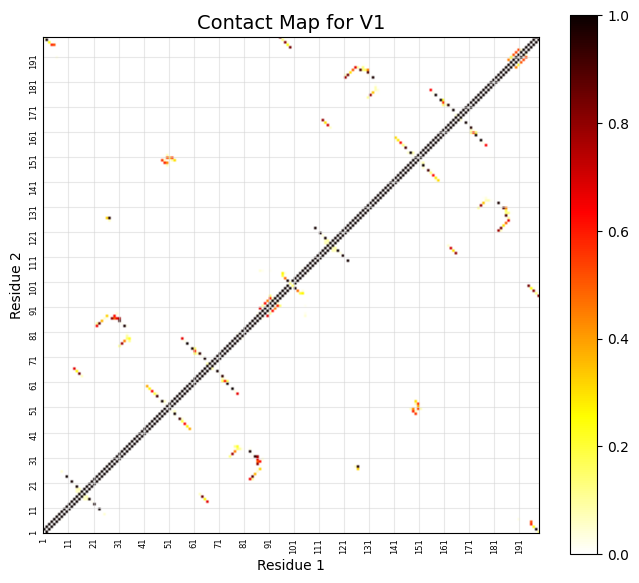

Contact data saved to V1_contact_matrix_analysis.csv


,Residue1,Residue2,Frequency
0,1,2,1.001220
1,1,197,0.008537
2,1,198,0.117073
3,2,1,1.001220
4,2,3,1.001220


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/tmp/ipykernel_79529/4118825598.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('hot')


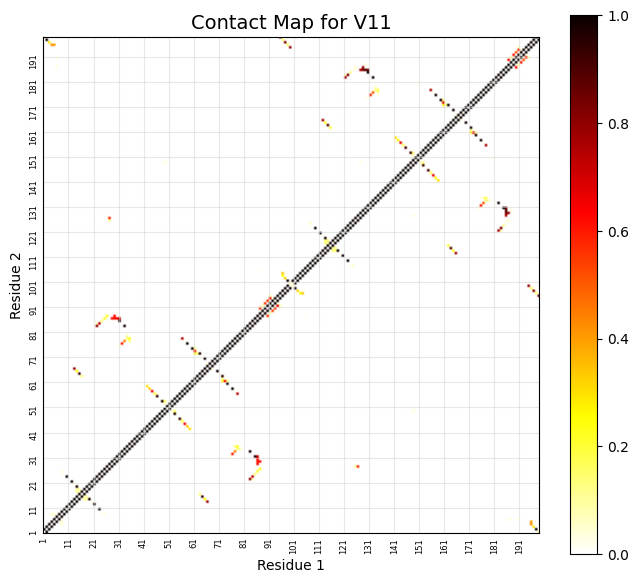

Contact data saved to V11_contact_matrix_analysis.csv


,Residue1,Residue2,Frequency
0,1,2,1.001220
1,1,198,0.110976
2,2,1,1.001220
3,2,3,1.001220
4,2,197,0.987805


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/tmp/ipykernel_79529/4118825598.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('hot')


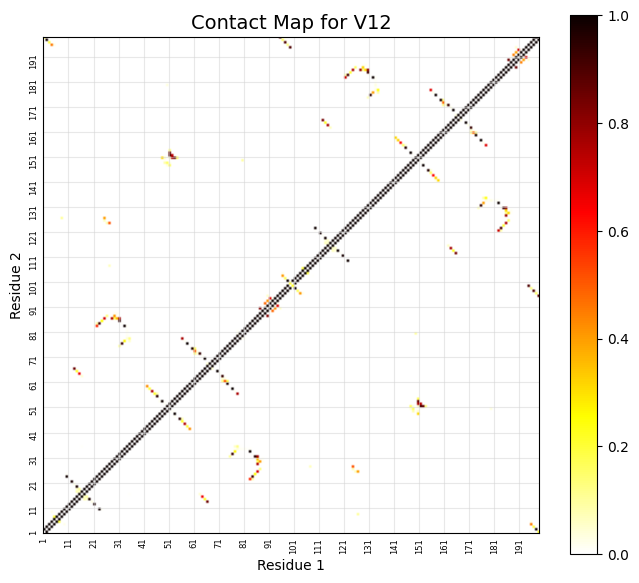

Contact data saved to V12_contact_matrix_analysis.csv


,Residue1,Residue2,Frequency
0,1,2,1.001220
1,1,197,0.003659
2,1,198,0.201220
3,2,1,1.001220
4,2,3,1.001220


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/tmp/ipykernel_79529/4118825598.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('hot')


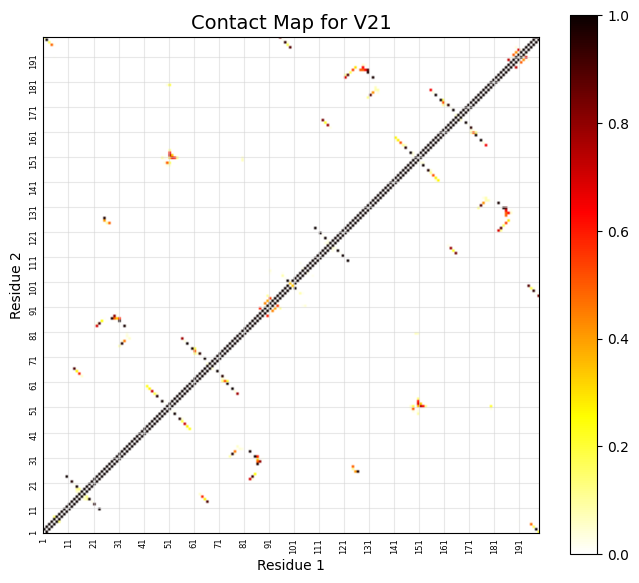

Contact data saved to V21_contact_matrix_analysis.csv


,Residue1,Residue2,Frequency
0,1,2,1.003125
1,1,197,0.006250
2,1,198,0.184375
3,2,1,1.003125
4,2,3,1.003125


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/tmp/ipykernel_79529/4118825598.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('hot')


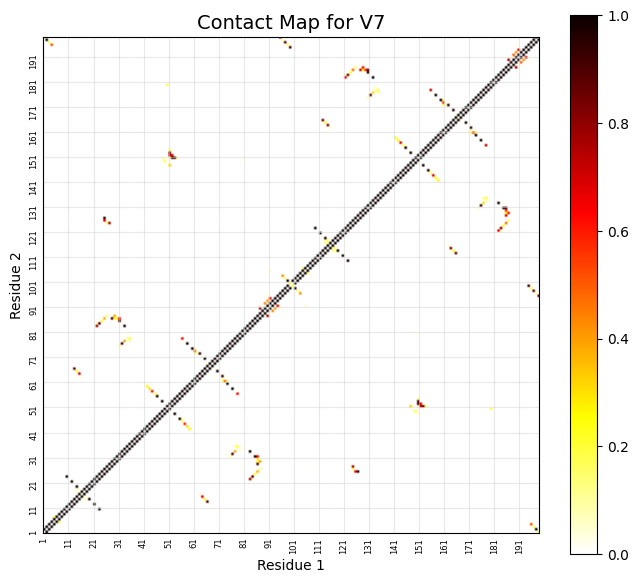

Contact data saved to V7_contact_matrix_analysis.csv


,Residue1,Residue2,Frequency
0,1,2,1.001220
1,1,197,0.007317
2,1,198,0.202439
3,2,1,1.001220
4,2,3,1.001220


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/tmp/ipykernel_79529/4118825598.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('hot')


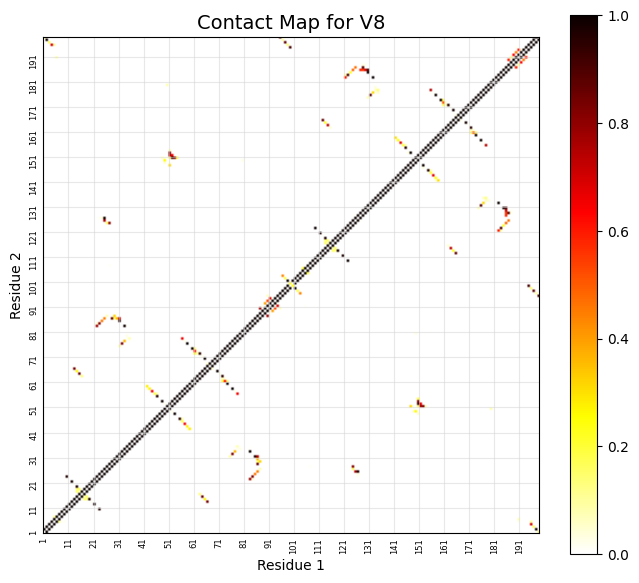

Contact data saved to V8_contact_matrix_analysis.csv


,Residue1,Residue2,Frequency
0,1,2,1.003125
1,1,198,0.140625
2,2,1,1.003125
3,2,3,1.003125
4,2,197,0.990625


In [ ]:
# 1. Fetch files from all simulations
sim_files = [] # For all simulations


for subdir, dirs, files in os.walk(rootdir):
    gro_files_pathnames = [f for f in files if f.endswith(".gro")]
    xtc_files_pathnames = [f for f in files if f.endswith(".xtc")]
    for gro_name in gro_files_pathnames:
        sim_name_match = gro_name.replace(".gro", "")
        found_xtc = None
        for xtc_name in xtc_files_pathnames:
            if sim_name_match in xtc_name  and xtc_name.endswith('.xtc'):
                found_xtc = xtc_name
                break
        if found_xtc:
            gro_path = os.path.join(subdir, gro_name)
            xtc_path = os.path.join(subdir, found_xtc)
            sim_files.append((gro_path, xtc_path))

# 1.1. sort file pairs
sim_files.sort()
all_sim_dist = []


if sim_name_match in phase_limit_dico:
    phase_limit = phase_limit_dico[sim_name_match]

for gro, xtc in sim_files:
    #load trajectory
    u = MDAnalysis.Universe(gro,xtc)
    timestep = 1
    n_frames = len(u.trajectory) - (phase_limit+1)
    start = phase_limit #phase 2
    #define your max_distance (cutoff, example 5.0)
    max_distance = 5.0

    sim_name = os.path.basename(os.path.dirname(gro))

    #select the regions to be measured against eachother from the trajecotry
    prot_seq = u.select_atoms('name CA and index 0:3073')
    n = len(prot_seq)

    # Initialize array for contacts
    contact_sum = numpy.zeros((n, n))

    # Sum 1 or 0 of each matrix position across timesteps
    for ts in u.trajectory[start::timestep]:
        prot_pos = prot_seq.positions
        ts_dist = cdist(prot_pos, prot_pos, 'euclidean')
        # Exclude self-contacts by setting diagonal elements to a value > max_distance
        numpy.fill_diagonal(ts_dist, max_distance + 1)

        # Apply the contact cutoff
        ts_dist[ts_dist < max_distance] = 1
        ts_dist[ts_dist >= max_distance] = 0 # Corrected from > to >=

        contact_sum = ts_dist + contact_sum

    contact_ratio = contact_sum / n_frames

    #---------------------------------------------------------------------------#
    # Basic imaging for intra-chain contacts
    #---------------------------------------------------------------------------#

    # Set x_min and y_min to the lowest residue index (example residue 50)
    cr_shape = contact_ratio.shape
    x_shift = cr_shape[1]
    y_shift = cr_shape[0]
    x_min = prot_seq.resids.min() # Use actual residue IDs for axes
    y_min = prot_seq.resids.min()
    x_max = x_min + x_shift -1 # Adjust max for proper range with min
    y_max = y_min + y_shift -1

    fig = plt.figure(figsize=(8, 7))
    im = plt.imshow(contact_ratio, vmin=0, vmax=1, aspect='equal', origin='lower',
                        extent=[x_min, x_max + 1, y_min, y_max + 1]) # Adjust extent to include full residues

    orig_map=plt.cm.get_cmap('hot')
    reversed_map = orig_map.reversed()
    im.set_cmap(reversed_map)

    plt.grid(visible=True, color='lightgrey', alpha=0.5)

    # Set ticks to correspond to residue IDs
    plt.xticks(numpy.arange(x_min, x_max + 1, 10), fontsize=10)
    plt.yticks(numpy.arange(y_min, y_max + 1, 10), fontsize=10)

    plt.xlabel(f'Residue 1', fontsize=10)
    plt.ylabel(f'Residue 2', fontsize=10)
    plt.title(f'Contact Map for {sim_name}', fontsize=14)
    plt.tick_params(axis='both', which='both', length=0, labelrotation=90, labelsize=6)

    colorbar()
    plt.show()

        # Create a list to store chain contact data
    contact_data= []

    # Get residue IDs for the chain analysis
    prot_resids = prot_seq.resindices + 1

    # Iterate through the contact_ratio_intra matrix
    for i in range(len(prot_resids)):
        for j in range(len(prot_resids)):
            frequency = contact_ratio[i, j]
            if frequency > 0 and frequency != 1: # Only record contacts with frequency greater than 0 and not
                res1 = prot_resids[i]
                res2 = prot_resids[j]
                contact_data.append({'Residue1': res1, 'Residue2': res2, 'Frequency': frequency})

    # Create a Pandas DataFrame for prot contacts
    contacts_df = pd.DataFrame(contact_data)

    # Define the output CSV file path
    output_csv_path = (f'{sim_name}_contact_matrix_analysis.csv')
    # Save to CSV
    contacts_df.to_csv(output_csv_path, index=False)

    print(f"Contact data saved to {output_csv_path}")
    display(contacts_df.head())